# Customer Segmentation Analysis using K-Means Clustering

## Oasis Infobyte Internship (OIBSIP)
### Level 1 - Task 2

**Name:** Sonia Negi

**Objective:**
The aim of this project is to segment customers based on their Annual Income and Spending Score using K-Means Clustering. The analysis helps businesses understand different customer groups and develop targeted marketing strategies.

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Display plots inside notebook
%matplotlib inline

# Improve plot appearance
sns.set_style("whitegrid")

In [2]:
#Loading Dataset
df= pd.read_csv("Mall_Customers.csv")

In [3]:
#Displaying first 5 rows of the dataset
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Understanding

In [4]:
# Dataset Shape
df.shape

(200, 5)

In [5]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# Missing Values
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
# Duplicate Values
df.duplicated().sum()

np.int64(0)

In [8]:
# Statistical Summary
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Observation

- The dataset contains *200 customer records* and *5 columns*.
- There are *4 numerical columns* and *1 categorical column (Genre)*.
- No missing values are present in the dataset.
- No duplicate records were found.
- The dataset is clean and ready for Exploratory Data Analysis (EDA) and Customer Segmentation.

# Exploratory Data Analysis (EDA)

### Customer Distribution by Genre

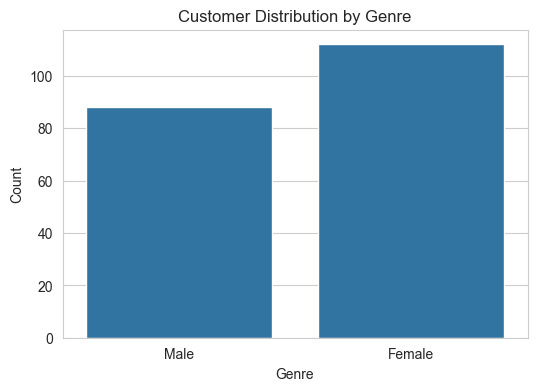

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Genre', data=df)
plt.title('Customer Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

### Observation:
1. The dataset contains slightly more female customers than male customers.
2. Both genders are well represented, making the dataset fairly balanced.

### Age Distribution

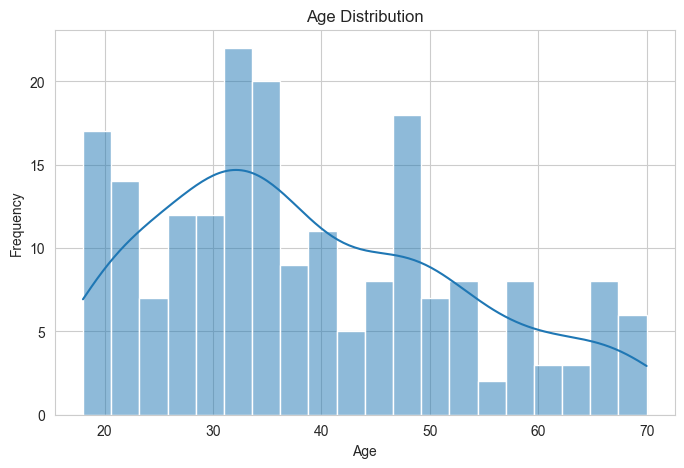

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Observation:
1. Most customers belong to the age group of 25–40 years.
2. The number of customers decreases gradually for higher age groups.


### Annual Income Distribution

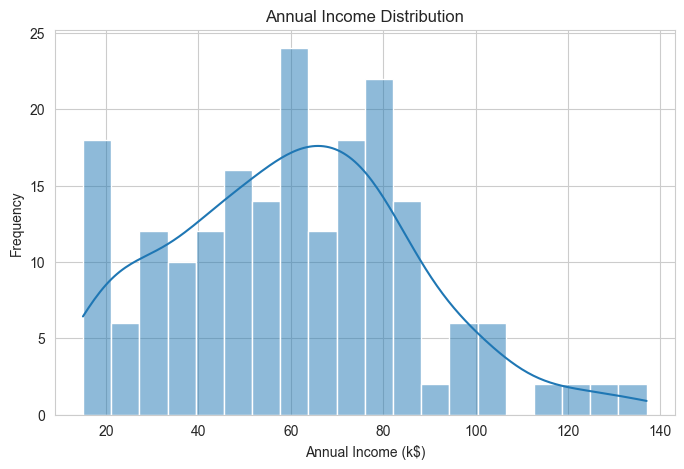

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.show()

### Observation:
1. Most customers have an annual income between 40k and 80k.
2. Very few customers belong to the extremely low or high income groups.

### Spending Score Distribution

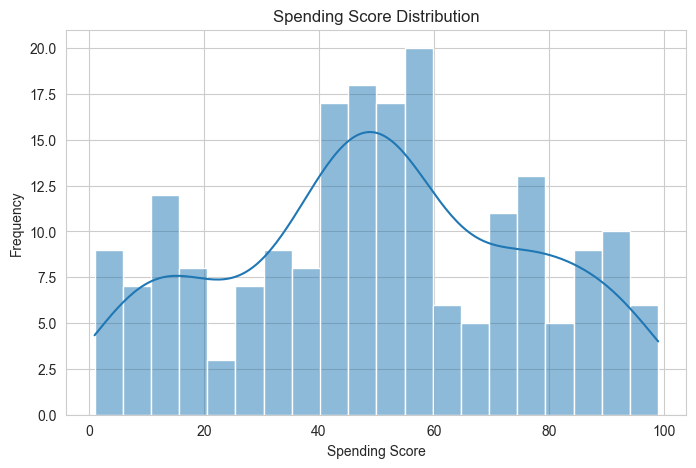

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Frequency')
plt.show()

### Observation:
1. Spending scores are spread across the entire range.
2. A large number of customers have medium spending scores (around 40–60), indicating varied purchasing behavior.

## Customer Segmentation (K-Means Clustering)

#### Select Features

In [13]:
X=df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


#### Finding the Optimal Number of Clusters (Elbow Method)

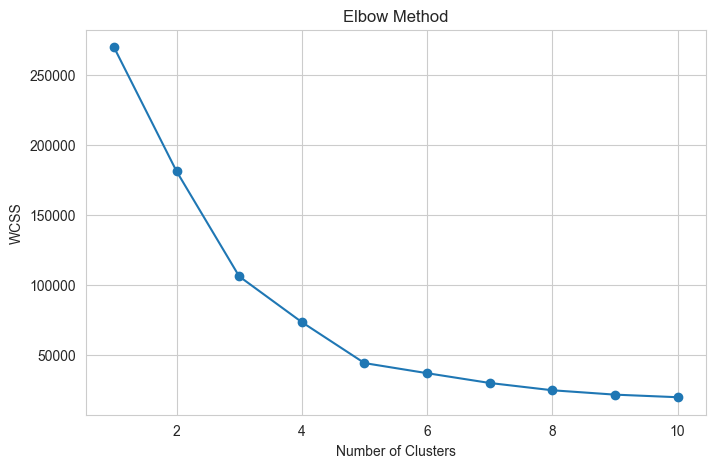

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

### Observation
1. The Elbow Method indicates that the optimal number of clusters is 5.
2. After K = 5, the decrease in WCSS becomes gradual, suggesting that five clusters provide the best balance between accuracy and simplicity.

#### Applying K-Means Clustering

In [15]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


#### Visualizing the Clusters

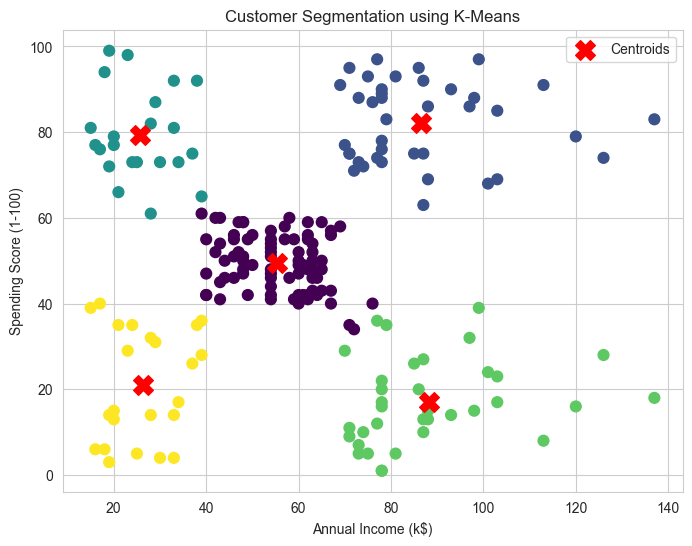

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis',
    s=60
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)
plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

### Observation

1. The K-Means algorithm successfully divided the customers into 5 distinct clusters based on Annual Income and Spending Score.
2. Customers with high income and high spending score form a valuable customer segment.
3. Customers with high income but low spending score represent potential customers who can be targeted with marketing strategies.
4. Customers with low income and high spending score are enthusiastic buyers despite lower income.
5. Customers with low income and low spending score contribute less to overall sales.
6. Customers with average income and average spending score form the largest and most stable customer segment.


## Business Insights

- Focus loyalty programs and premium offers on high-income, high-spending customers.
- Create personalized discounts and promotions to encourage high-income, low-spending customers to purchase more.
- Offer affordable products and seasonal deals for low-income customer groups.
- Maintain customer engagement for the average-income, average-spending segment, as they represent a stable source of revenue.
- Customer segmentation helps businesses design targeted marketing campaigns, improve customer satisfaction, and increase overall sales.

# Final Conclusion
This project successfully performed customer segmentation using the K-Means Clustering algorithm. Exploratory Data Analysis (EDA) helped understand the distribution of customer demographics, income, and spending behavior. 

The Elbow Method identified 5 as the optimal number of clusters. Based on annual income and spending score, customers were divided into five meaningful groups with different purchasing patterns. 

These insights can help businesses develop targeted marketing strategies, improve customer engagement, and maximize revenue by focusing on the needs of each customer segment.